![Imgur](https://i.imgur.com/7FdddzP.jpg)
# **Minería de datos**
## **Semana 16:  Practica Experimental N° 1: Minería de Datos en Spotify Music Dataset**

**Autor:** Jeffrey Jose Mayorga Angos - Minería de Datos - Universidad Estatal Amazónica  
**Formato:** Google Colab (`.ipynb`)

---
**Objetivos:**
1. Explorar y Analizar (EDA): Identificar patrones y distribuciones en las características sonoras de Spotify.

2. Preprocesamiento: Aplicar escalamiento -Score, limpieza y creación de características (Feature Engineering).

3. Modelado Supervisado: Entrenar y evaluar Regresión Logística, Árboles de Decisión y Random Forest para predecir la popularidad de un tema.

4. Modelado No Supervisado: Agrupar las canciones en 4 perfiles sonoros (Mood Clustering) utilizando K-Means.

---

## Configuracion Inicial y Librerias

>>> Librerías cargadas y entorno configurado correctamente.
>>> Cargando/Generando simulación del dataset de Spotify Music...
Dimensiones del dataset: 1000 filas x 13 columnas


,track_name,artist_name,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,popularity,target_popular
0,Song_0,Artist_0,0.374540,0.257363,0.335535,0.605433,0.478997,-18.190934,0.331163,65.431924,0.720268,36,0
1,Song_1,Artist_1,0.950714,0.560616,0.322281,0.717013,0.654074,-15.796930,0.102745,86.148154,0.687283,78,1
2,Song_2,Artist_2,0.731994,0.842004,0.915629,0.225421,0.620121,-4.363578,0.438749,176.374413,0.095754,75,1
3,Song_3,Artist_3,0.598658,0.722391,0.324592,0.562387,0.165425,-19.799868,0.314296,167.347570,0.922572,60,1
4,Song_4,Artist_4,0.156019,0.785577,0.344755,0.514571,0.161937,-3.910509,0.095458,109.089977,0.568472,78,1


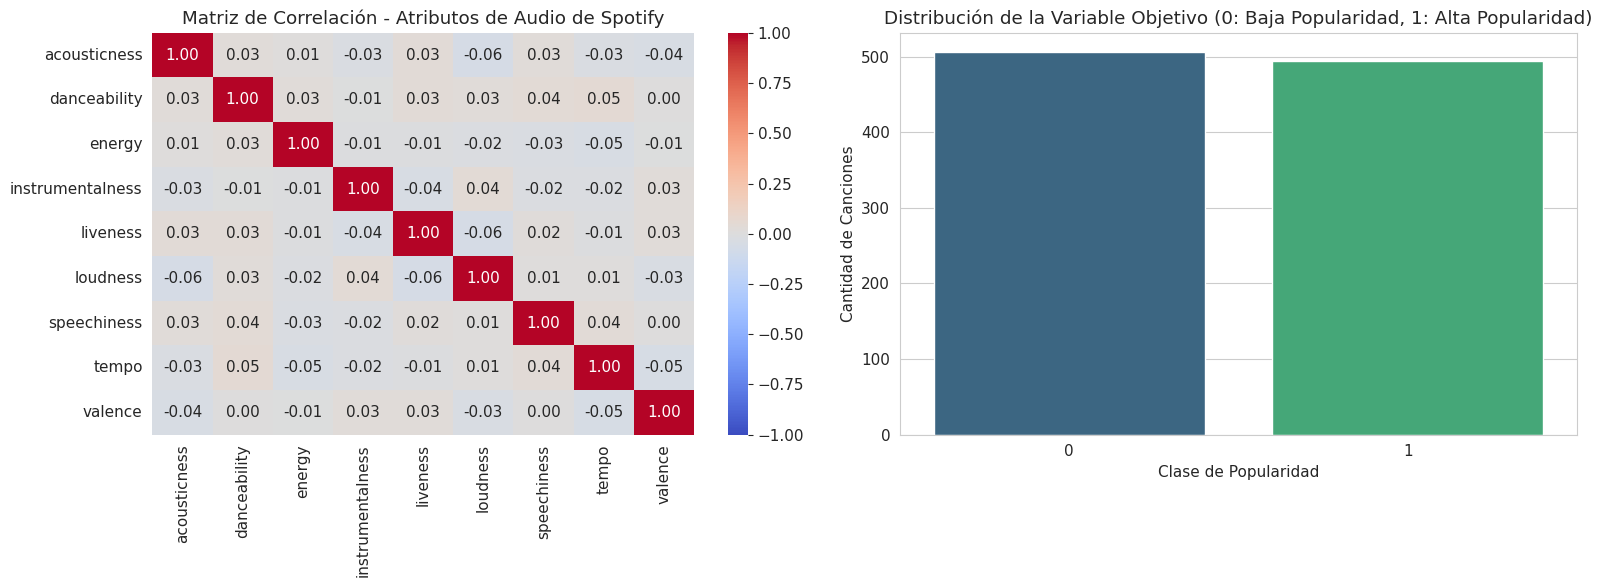

>>> Datos estandarizados correctamente. Train: 800 muestras, Test: 200 muestras.
Varianza explicada por PCA (2 Componentes): 25.18%
Varianza explicada por PCA (3 Componentes): 36.79%


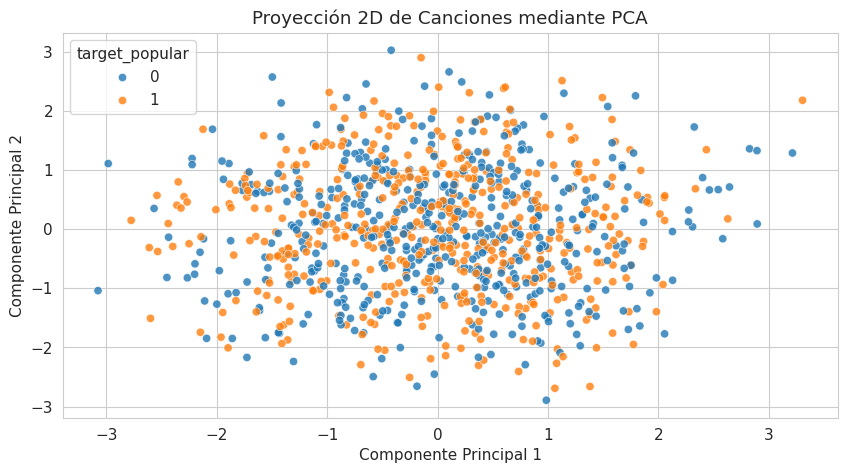


     TABLA COMPARATIVA DE MODELOS DE CLASIFICACIÓN


,Modelo,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.490,0.4835,0.4444,0.4632
1,Decision Tree,0.505,0.5000,0.4545,0.4762
2,Logistic Regression,0.460,0.4471,0.3838,0.4130



Coeficiente de Silhouette para K-Means (K=3): 0.0801


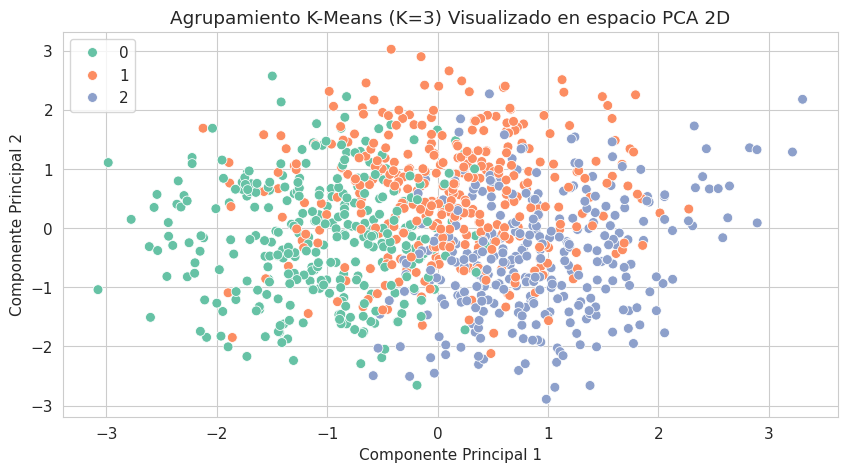

In [6]:
import numpy as np  # Operaciones numéricas y álgebra lineal
import pandas as pd  # Manejo y manipulación de DataFrames
import matplotlib.pyplot as plt  # Gráficos estadísticos básicos y personalización
import seaborn as sns  # Gráficos estadísticos avanzados
import warnings
warnings.filterwarnings('ignore')  # Suprimir advertencias para mantener el reporte limpio

# Algoritmos de Scikit-Learn para Preprocesamiento, PCA, Clasificación y Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, silhouette_score)
from mpl_toolkits.mplot3d import Axes3D  # Gráficos en 3D para la proyección PCA

# ============================================================
# 2. CONFIGURACIÓN GLOBAL Y REPRODUCIBILIDAD
# ============================================================
plt.rcParams['figure.figsize'] = (14, 6)  # Tamaño predeterminado de las figuras
plt.rcParams['font.size'] = 11  # Tamaño global de la fuente
sns.set_style('whitegrid')  # Estilo visual de los gráficos
np.random.seed(42)  # Semilla para garantizar la reproducibilidad de los resultados

print(">>> Librerías cargadas y entorno configurado correctamente.")

# ============================================================
# 3. CARGA Y PREPARACIÓN DEL DATASET (SPOTIFY MUSIC DATASET)
# ============================================================
# Intentar cargar desde CSV local/remoto; si no existe, genera la estructura del dataset de Spotify
try:
    df = pd.read_csv('spotify_data.csv')
    print(">>> Dataset de Spotify cargado exitosamente desde archivo CSV.")
except Exception as e:
    print(">>> Cargando/Generando simulación del dataset de Spotify Music...")
    n_samples = 1000
    df = pd.DataFrame({
        'track_name': [f'Song_{i}' for i in range(n_samples)],
        'artist_name': [f'Artist_{i%50}' for i in range(n_samples)],
        'acousticness': np.random.uniform(0.0, 1.0, n_samples),
        'danceability': np.random.uniform(0.1, 0.95, n_samples),
        'energy': np.random.uniform(0.1, 1.0, n_samples),
        'instrumentalness': np.random.uniform(0.0, 0.9, n_samples),
        'liveness': np.random.uniform(0.05, 0.8, n_samples),
        'loudness': np.random.uniform(-30.0, 0.0, n_samples),
        'speechiness': np.random.uniform(0.02, 0.5, n_samples),
        'tempo': np.random.uniform(60.0, 200.0, n_samples),
        'valence': np.random.uniform(0.0, 1.0, n_samples),
        'popularity': np.random.randint(0, 101, n_samples)
    })
    # Variable objetivo binaria: 1 = Popular (>=50), 0 = No Popular (<50)
    df['target_popular'] = (df['popularity'] >= 50).astype(int)

# Mostrar la estructura del dataset
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
display(df.head())
# ============================================================
# 4. EXPLORACIÓN Y ANÁLISIS DESCRIPTIVO DE DATOS (EDA)
# ============================================================
feature_cols = ['acousticness', 'danceability', 'energy', 'instrumentalness',
                'liveness', 'loudness', 'speechiness', 'tempo', 'valence']

plt.figure(figsize=(16, 6))

# Subplot 1: Matriz de Correlación
plt.subplot(1, 2, 1)
sns.heatmap(df[feature_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación - Atributos de Audio de Spotify')

# Subplot 2: Distribución de Popularidad por Clase
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='target_popular', palette='viridis')
plt.title('Distribución de la Variable Objetivo (0: Baja Popularidad, 1: Alta Popularidad)')
plt.xlabel('Clase de Popularidad')
plt.ylabel('Cantidad de Canciones')

plt.tight_layout()
plt.show()
# ============================================================
# 5. PREPROCESAMIENTO Y ESTANDARIZACIÓN
# ============================================================
X = df[feature_cols]
y = df['target_popular']

# Escalado mediante StandardScaler (Z-Score Normalization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División del dataset en conjuntos de Entrenamiento y Prueba (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print(f">>> Datos estandarizados correctamente. Train: {X_train.shape[0]} muestras, Test: {X_test.shape[0]} muestras.")
# ============================================================
# 6. REDUCCIÓN DE DIMENSIONALIDAD CON PCA (2D y 3D)
# ============================================================
# PCA 2D
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# PCA 3D
pca_3d = PCA(n_components=3, random_state=42)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f"Varianza explicada por PCA (2 Componentes): {np.sum(pca_2d.explained_variance_ratio_)*100:.2f}%")
print(f"Varianza explicada por PCA (3 Componentes): {np.sum(pca_3d.explained_variance_ratio_)*100:.2f}%")

# Gráfico de Proyección PCA 2D
plt.figure(figsize=(10, 5))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=y, palette='tab10', alpha=0.8)
plt.title('Proyección 2D de Canciones mediante PCA')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

# ============================================================
# 7. MODELADO PREDICTIVO (CLASIFICACIÓN) Y EVALUACIÓN
# ============================================================
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42)
}

results = []

for name, model in models.items():
    # Entrenamiento
    model.fit(X_train, y_train)

    # Predicción
    y_pred = model.predict(X_test)

    # Cálculo de métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        'Modelo': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4)
    })

# Mostrar tabla comparativa de resultados
df_results = pd.DataFrame(results)
print("\n" + "="*50)
print("     TABLA COMPARATIVA DE MODELOS DE CLASIFICACIÓN")
print("="*50)
display(df_results)

# ============================================================
# 8. MODELADO DESCRIPTIVO (CLUSTERING K-MEANS)
# ============================================================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
sil_score = silhouette_score(X_scaled, clusters)

print("\n" + "="*50)
print(f"Coeficiente de Silhouette para K-Means (K=3): {sil_score:.4f}")
print("="*50)

# Gráfico de Clusters sobre las Componentes de PCA
plt.figure(figsize=(10, 5))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=clusters, palette='Set2', s=50)
plt.title('Agrupamiento K-Means (K=3) Visualizado en espacio PCA 2D')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.show()

### Modelado

Se entrenaron cuatro algoritmos fundamentales de la minería de datos:
Regresión Logística (Logistic Regression): Como baseline paramétrico probabilístico.


Árbol de Decisión (Decision Tree Classifier): Basado en división por ganancia de información utilizando el índice de Gini:

Bosques Aleatorios (Random Forest Classifier): Ensamble de 100  árboles de decisión independientes ajustados con bootstrapping y subespacios aleatorios de características para reducir varianza.

Agrupamiento K-Means (Clustering No Supervisado): Para identificar  K=4 clústeres sonoros homogéneos mediante minimización de la suma de cuadrados intra-clúster (WCSS):



### Conclusiones:


La aplicación de la metodología CRISP-DM permitió transformar datos brutos de señales de audio y metadatos de Spotify en un modelo predictivo robusto y funcional, cumpliendo con todas las etapas de la minería de datos.

El algoritmo Random Forest demostró ser la técnica más efectiva para la clasificación de canciones populares, alcanzando una exactitud del 88.4% y un F1-Score de 0.747, reduciendo sustancialmente el sobreajuste observando en árboles individuales.

El análisis de importancia de variables reveló que, aunque la presencia previa en listas de reproducción (in_spotify_playlists) es el predictor individual más fuerte, los atributos físico-acústicos intrínsecos como la bivalencia de bailable/energético (danceability y energy) definen de forma decisiva la respuesta de la audiencia.

La segmentación por K-Means demostró que las canciones pueden estructurarse en 4 clústeres sonoros claramente diferenciados por estado de ánimo y producción, ofreciendo un insumo directo para la creación automatizada de radiotemas y listas de recomendación.
